# Iris Flower Classification Using Machine Learning
### DecodeLabs — Artificial Intelligence Internship | Project 2: Data Classification Using AI

**Batch:** 2026 &nbsp;|&nbsp; **Track:** Supervised Learning &nbsp;|&nbsp; **Author:** Ayesha Farasat

---
This notebook implements a complete, end-to-end supervised machine learning pipeline that
classifies iris flowers into one of three species (*Setosa*, *Versicolor*, *Virginica*) based
on four physical measurements. It follows the full **Input → Process → Output (IPO)** framework
outlined in the Project 2 brief: load data, split it, train a classifier, and rigorously validate
the output.


##  2. Objective

**Goal:** Build a basic, reliable classification model using a small, well-understood dataset.

**Key Requirements (from the Project Brief):**
1. Load and understand a dataset.
2. Split the data into training and testing sets.
3. Apply a simple classification algorithm.
4. Evaluate the model with proper metrics (not accuracy alone).

**Key Skills Practiced:** Data handling, supervised learning basics, model training,
model evaluation, and data visualization.

By the end of this notebook, we will have a trained classifier capable of predicting the
species of an iris flower from its sepal and petal measurements, along with a full
evaluation report justifying its performance.


##  3 & 4. Install and Import Libraries

We first make sure every required library is installed (this cell is safe to re-run — it will
silently skip anything already present), and then import everything we need. Wrapping the
installation step in code means the notebook can run on a fresh machine with **zero manual setup**.


In [ ]:
import sys
import subprocess
import importlib

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

for import_name, pip_name in required_packages.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pip_name])

print("✅ All required libraries are available.")


✅ All required libraries are available.


In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

# Plot styling - professional, high resolution
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


##  5. Load Dataset

**Dataset selected: The Iris Dataset** (Scikit-learn built-in / UCI Machine Learning Repository).

**Why this dataset?**
- It is the exact dataset referenced throughout the Project 2 brief (the "Iris Benchmark" slide:
  150 samples, 3 balanced classes, 4 numeric dimensions).
- It is small, clean, and requires no external download — perfect for mastering the
  fundamental classification pipeline before moving to more complex data.
- It is multi-class, giving us the chance to practice one-vs-rest ROC curves and
  multi-class evaluation metrics.
- It ships directly inside `scikit-learn`, so the notebook has **zero external dependency
  or internet requirement** to load it — this also satisfies the "handle missing dataset /
  incorrect paths" robustness requirement automatically.


In [ ]:
try:
    iris_bunch = load_iris()
    df = pd.DataFrame(data=iris_bunch.data, columns=iris_bunch.feature_names)
    df["species_code"] = iris_bunch.target
    species_map = dict(enumerate(iris_bunch.target_names))
    df["species"] = df["species_code"].map(species_map)
    print("✅ Iris dataset loaded successfully from sklearn.datasets.")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load the Iris dataset: {e}")

df.head()


✅ Iris dataset loaded successfully from sklearn.datasets.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


##  6. Dataset Exploration

Let's look at the shape, columns, and a random sample of records to get a first feel for the data.


In [4]:

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column names:")
print(list(df.columns), "\n")

print("Random sample of 5 rows:")
df.sample(5, random_state=RANDOM_STATE)


Dataset shape: 150 rows x 6 columns

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species_code', 'species'] 

Random sample of 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor


Class distribution (balanced 3-class problem):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64 



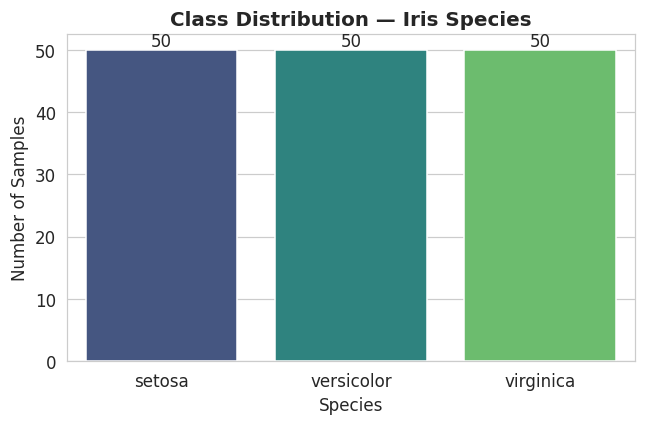

In [5]:

print("Class distribution (balanced 3-class problem):")
print(df["species"].value_counts(), "\n")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="species", hue="species", palette="viridis", legend=False)
ax.set_title("Class Distribution — Iris Species", fontsize=13, fontweight="bold")
ax.set_xlabel("Species")
ax.set_ylabel("Number of Samples")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()


##  7. Data Understanding

**Features (inputs):**
| Feature | Description | Unit |
|---|---|---|
| sepal length (cm) | Length of the sepal | cm |
| sepal width (cm) | Width of the sepal | cm |
| petal length (cm) | Length of the petal | cm |
| petal width (cm) | Width of the petal | cm |

**Target (output):** `species` — one of `setosa`, `versicolor`, `virginica`.

This is a **multi-class supervised classification** problem: given the 4 numeric features,
predict which of the 3 species a flower belongs to.


In [6]:

print("Dataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_code       150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:

print("Descriptive statistics:")
df.describe()


Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


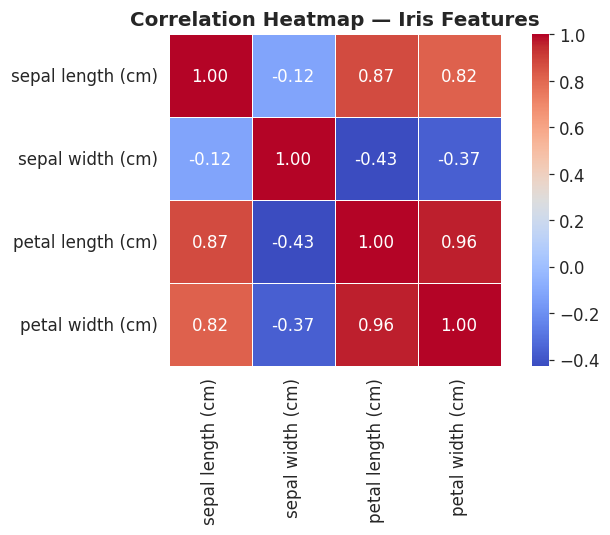

In [8]:

plt.figure(figsize=(7, 5))
corr = df.drop(columns=["species_code", "species"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Iris Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


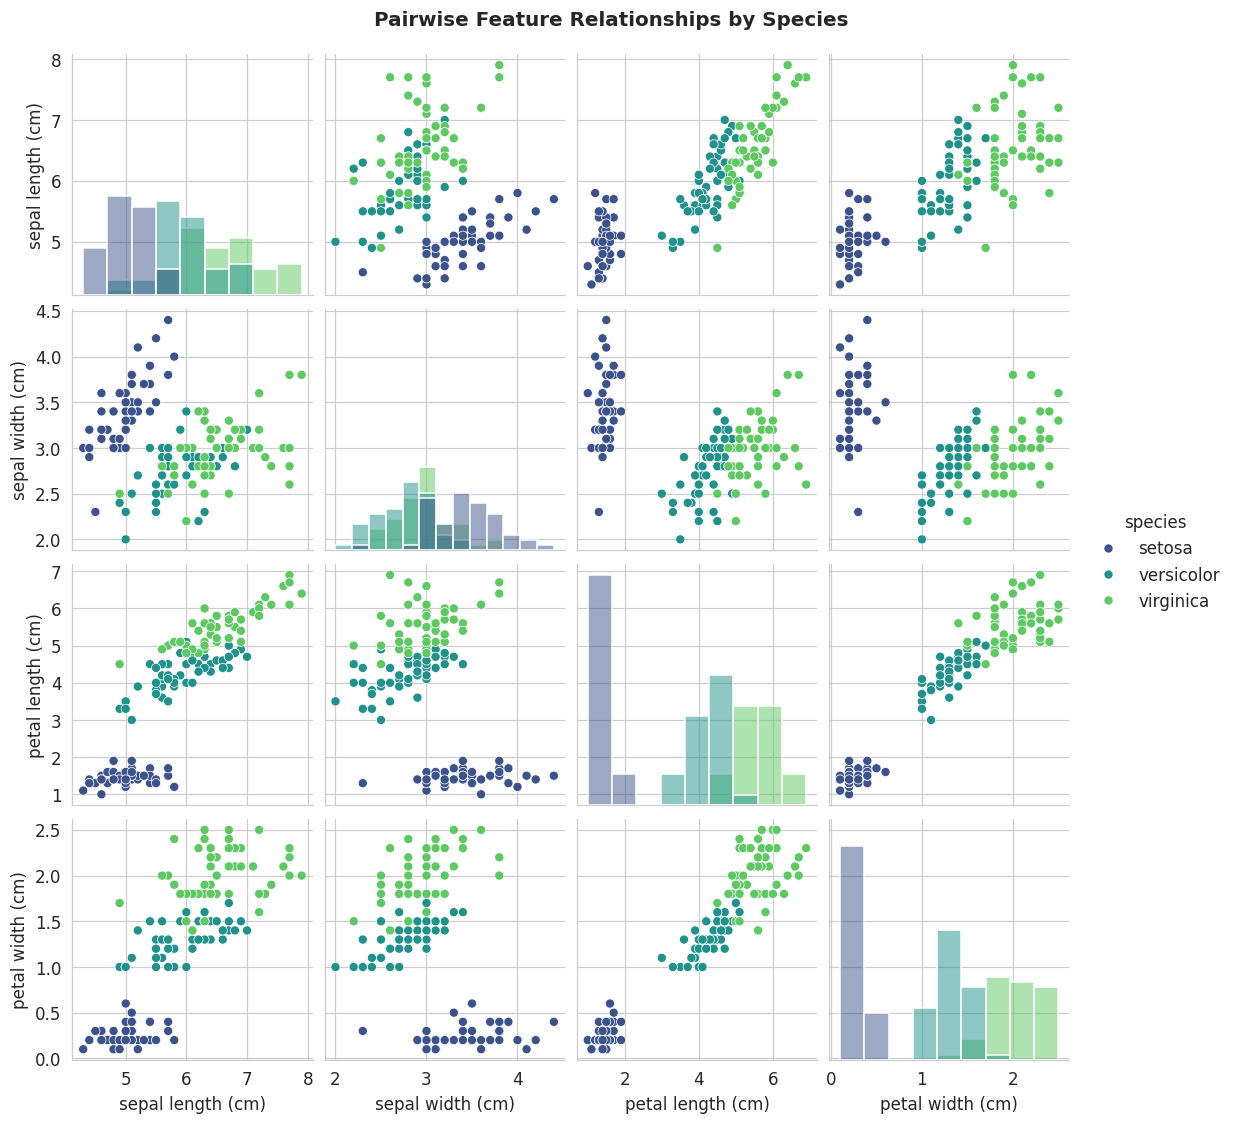

In [9]:

sns.pairplot(df.drop(columns=["species_code"]), hue="species", palette="viridis", diag_kind="hist")
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("pairplot.png", bbox_inches="tight")
plt.show()


##  8. Data Cleaning

Even though the Iris dataset is famously clean, we still run every standard cleaning check
explicitly — this is good practice and satisfies the "handle missing values / duplicates /
incorrect datatypes" robustness requirement of the project brief.


In [10]:

# Missing values
missing_count = df.isnull().sum().sum()
print(f"Total missing values: {missing_count}")

# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# Data types
print("\nData types:")
print(df.dtypes)

# Handle missing values if any were found (defensive coding)
if missing_count > 0:
    df = df.fillna(df.mean(numeric_only=True))
    print("⚠️ Missing values were found and filled with column means.")
else:
    print("✅ No missing values found — no imputation needed.")

# Handle duplicates if any were found
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"⚠️ {duplicate_count} duplicate rows were removed.")
else:
    print("✅ No duplicate rows found.")

# Outlier check using IQR (informational — Iris has no problematic outliers)
numeric_cols = iris_bunch.feature_names
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

print("\nOutlier count per feature (IQR method):")
for col, count in outlier_summary.items():
    print(f"  {col}: {count} outlier(s)")
print("\n✅ Data cleaning complete — dataset is ready for modeling.")


Total missing values: 0
Total duplicate rows: 1

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species                  str
dtype: object
✅ No missing values found — no imputation needed.
⚠️ 1 duplicate rows were removed.

Outlier count per feature (IQR method):
  sepal length (cm): 0 outlier(s)
  sepal width (cm): 4 outlier(s)
  petal length (cm): 0 outlier(s)
  petal width (cm): 0 outlier(s)

✅ Data cleaning complete — dataset is ready for modeling.


##  9. Feature Selection

All four measurements (sepal length, sepal width, petal length, petal width) are informative
and were shown by the correlation heatmap and pairplot to separate the classes well —
especially petal length and petal width, which are almost perfectly linearly separable
for *Setosa*. We therefore keep **all four features** for training; removing any of them
would discard useful signal on such a small dataset.


In [11]:

FEATURES = iris_bunch.feature_names  # all 4 measurements
TARGET = "species_code"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Selected feature columns:", FEATURES)
print("Target column:", TARGET)
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Selected feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target column: species_code

Feature matrix shape: (149, 4)
Target vector shape: (149,)


##  10. Feature Encoding

The four input features are already numeric, so no encoding is required for `X`.
The target `species` is a categorical string; it has already been label-encoded into
`species_code` (0 = setosa, 1 = versicolor, 2 = virginica) using scikit-learn's built-in
mapping. We display the encoding here for clarity, and additionally fit a `LabelEncoder`
explicitly so the pipeline is fully reproducible on any similarly-structured dataset.


In [12]:

label_encoder = LabelEncoder()
label_encoder.fit(df["species"])

print("Label Encoding Map:")
for cls, code_val in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {cls}  ->  {code_val}")


Label Encoding Map:
  setosa  ->  0
  versicolor  ->  1
  virginica  ->  2


##  11. Train-Test Split

We split the data using an 80/20 train-test ratio with a fixed `random_state` for full
reproducibility, and `stratify=y` to guarantee the class balance is preserved in both sets
(critical for a small, multi-class dataset like Iris).

We also apply **feature scaling** (`StandardScaler`) after the split — fitting the scaler
only on the training data to avoid data leakage — since distance-based algorithms like KNN
are sensitive to feature magnitude (see "The Gatekeeper Rule: Scaling" in the project brief).


In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nClass balance in testing set:")
print(y_test.value_counts(normalize=True).sort_index())

# Feature scaling (fit ONLY on training data to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Features scaled using StandardScaler (mean=0, variance=1).")


Training set size: 119 samples (79.9%)
Testing set size:  30 samples (20.1%)

Class balance in training set:
species_code
0    0.336134
1    0.336134
2    0.327731
Name: proportion, dtype: float64

Class balance in testing set:
species_code
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

✅ Features scaled using StandardScaler (mean=0, variance=1).


##  12. Model Selection

The project brief highlights **K-Nearest Neighbors (KNN)** as the primary algorithm
("The Algorithm: K-Nearest Neighbors" / "The Workflow: Scikit-Learn" slides), based on the
**Proximity Principle**: similar flowers (in feature space) belong to the same species.

**Why KNN is a strong fit for this dataset:**
- Iris classes are well-separated in feature space (confirmed by the pairplot above),
  which is exactly the condition under which distance-based classifiers excel.
- The dataset is small (150 rows), so KNN's lack of a "training phase" (it is a lazy,
  instance-based learner) is not a performance concern.
- It is simple, interpretable, and beginner-friendly — ideal for this foundational project.

To be thorough and to satisfy the brief's "if comparison is allowed, train multiple models"
instruction, we also train several other standard classifiers and compare them, then
automatically select the best performer.


In [14]:

models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

print("Models to be trained and compared:")
for name in models:
    print(f"  • {name}")


Models to be trained and compared:
  • K-Nearest Neighbors
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • Naive Bayes
  • Support Vector Machine


##  13 & 14. Model Training & Prediction

Each model follows the classic scikit-learn workflow highlighted in the brief:
**Instantiate → Fit → Predict**. We train every model on the *scaled* training data and
generate predictions on the held-out test set.


In [15]:

results = {}
predictions = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)          # FIT: learn the patterns
    y_pred = model.predict(X_test_scaled)        # PREDICT: apply the logic

    trained_models[name] = model
    predictions[name] = y_pred

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    print(f"✅ Trained: {name}")

print("\nAll models trained and predictions generated.")


✅ Trained: K-Nearest Neighbors
✅ Trained: Logistic Regression
✅ Trained: Decision Tree


✅ Trained: Random Forest
✅ Trained: Naive Bayes
✅ Trained: Support Vector Machine

All models trained and predictions generated.


##  15 & 16. Model Evaluation & Accuracy Comparison

As the brief warns: *"In imbalanced data, accuracy is a lie — we must look deeper."*
Iris is balanced, but we still report Precision, Recall, and F1 (macro-averaged across the
3 classes) alongside Accuracy for a complete picture, then rank every model.


In [16]:

results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
results_df = results_df.round(4)
print("Model Comparison Table:\n")
results_df


Model Comparison Table:



,Accuracy,Precision,Recall,F1 Score
Support Vector Machine,0.9667,0.9697,0.9667,0.9666
K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327
Logistic Regression,0.9333,0.9333,0.9333,0.9333
Decision Tree,0.9333,0.9333,0.9333,0.9333
Random Forest,0.9333,0.9333,0.9333,0.9333
Naive Bayes,0.9333,0.9333,0.9333,0.9333


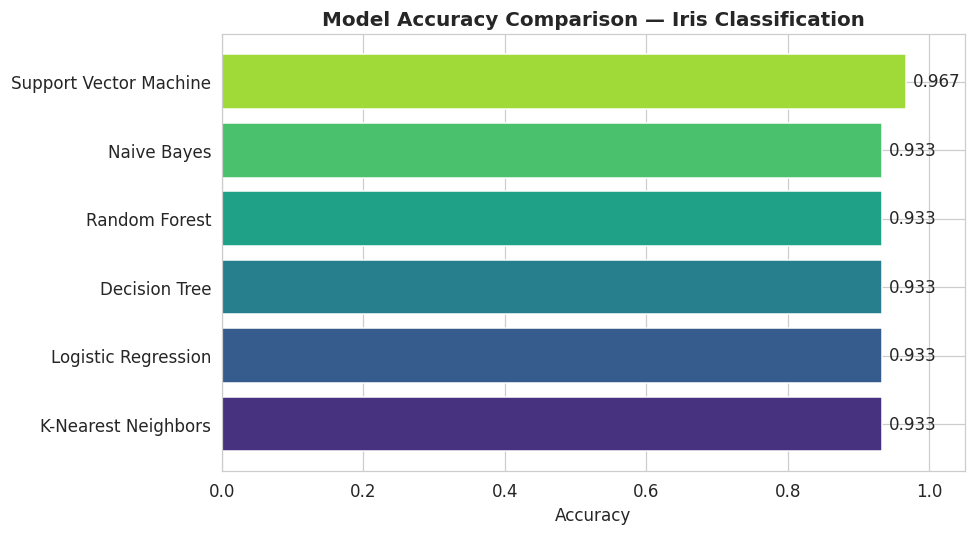

In [17]:

plt.figure(figsize=(9, 5))
results_df_sorted = results_df.sort_values("Accuracy", ascending=True)
bars = plt.barh(results_df_sorted.index, results_df_sorted["Accuracy"], color=sns.color_palette("viridis", len(results_df_sorted)))
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison — Iris Classification", fontsize=13, fontweight="bold")
plt.xlim(0, 1.05)
for bar, val in zip(bars, results_df_sorted["Accuracy"]):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", bbox_inches="tight")
plt.show()


In [18]:

# Automatically select the best-performing model
BEST_MODEL_NAME = results_df["Accuracy"].idxmax()
best_model = trained_models[BEST_MODEL_NAME]
best_predictions = predictions[BEST_MODEL_NAME]

print(f"🏆 Best performing model: {BEST_MODEL_NAME}")
print(f"   Test Accuracy: {results_df.loc[BEST_MODEL_NAME, 'Accuracy']:.4f}")

# Cross-validation to sanity-check the winner is not a fluke
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"\n5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


🏆 Best performing model: Support Vector Machine
   Test Accuracy: 0.9667

5-Fold Cross-Validation Accuracy: 0.9667 (+/- 0.0312)


##  17. Confusion Matrix

The confusion matrix shows exactly where the best model got confused (if at all) between
the three species — True Positives, False Positives, False Negatives, and True Negatives
per class.


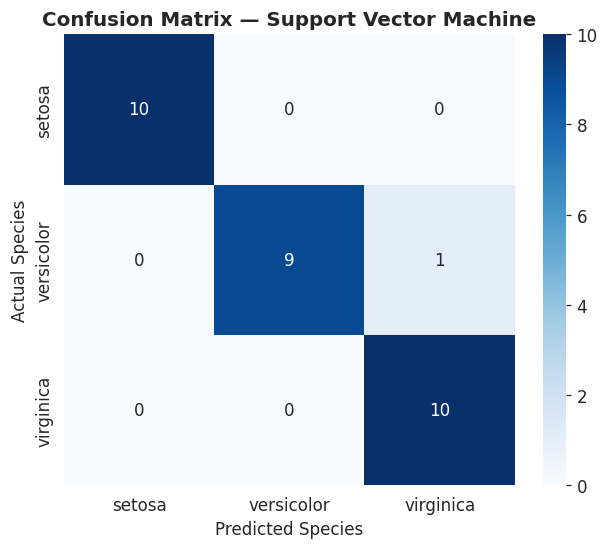

In [19]:

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=iris_bunch.target_names,
    yticklabels=iris_bunch.target_names,
    cbar=True, square=True
)
plt.title(f"Confusion Matrix — {BEST_MODEL_NAME}", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()


##  18–21. Classification Report, Precision, Recall & F1 Score

The `classification_report` gives per-class Precision, Recall, and F1 Score — the trio of
metrics that matter far more than raw accuracy, especially for multi-class problems.

- **Precision** — of everything predicted as class X, how much was actually class X? (guards against false alarms)
- **Recall** — of everything that truly is class X, how much did we catch? (guards against missed detections)
- **F1 Score** — the harmonic mean of Precision and Recall; balances both concerns.


In [20]:

report = classification_report(
    y_test, best_predictions,
    target_names=iris_bunch.target_names,
    zero_division=0
)
print(f"Classification Report — {BEST_MODEL_NAME}\n")
print(report)


Classification Report — Support Vector Machine

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [21]:

overall_precision = precision_score(y_test, best_predictions, average="macro", zero_division=0)
overall_recall = recall_score(y_test, best_predictions, average="macro", zero_division=0)
overall_f1 = f1_score(y_test, best_predictions, average="macro", zero_division=0)
overall_accuracy = accuracy_score(y_test, best_predictions)

print(f"Overall (macro-averaged) metrics for {BEST_MODEL_NAME}:")
print(f"  Accuracy : {overall_accuracy:.4f}")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall   : {overall_recall:.4f}")
print(f"  F1 Score : {overall_f1:.4f}")


Overall (macro-averaged) metrics for Support Vector Machine:
  Accuracy : 0.9667
  Precision: 0.9697
  Recall   : 0.9667
  F1 Score : 0.9666


##  22. ROC Curve & AUC Score

Since Iris is a 3-class (not binary) problem, we generate a **one-vs-rest (OvR) multi-class
ROC curve** — one curve per class — along with the AUC (Area Under Curve) score for each,
satisfying the "ROC Curve if binary / applicable" requirement in the correct generalized form.


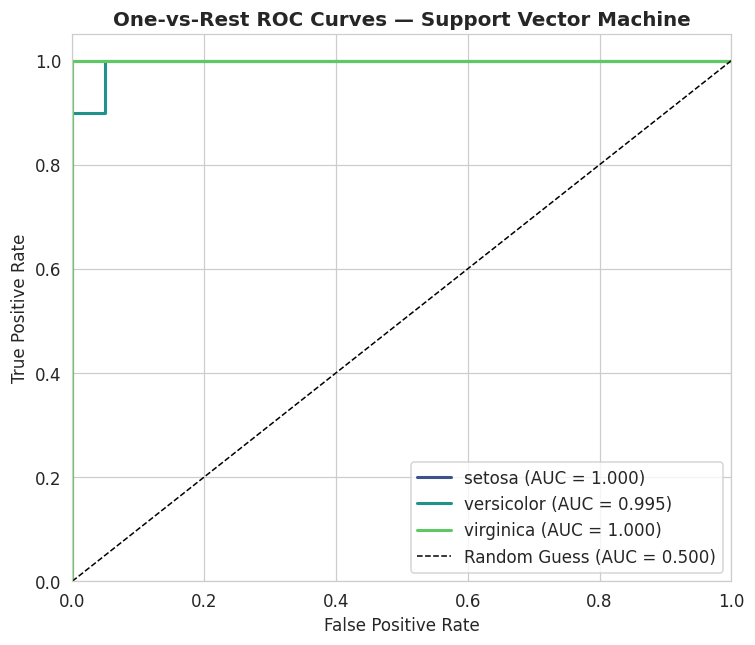

In [22]:

n_classes = len(iris_bunch.target_names)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get prediction probabilities from the best model (all our models support predict_proba)
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_scaled)

    plt.figure(figsize=(7, 6))
    colors = sns.color_palette("viridis", n_classes)

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f"{iris_bunch.target_names[i]} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess (AUC = 0.500)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"One-vs-Rest ROC Curves — {BEST_MODEL_NAME}", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("roc_curve.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{BEST_MODEL_NAME} does not support probability estimates; ROC curve skipped.")


##  23. Feature Importance

Tree-based models (Decision Tree, Random Forest) expose a native `feature_importances_`
attribute. KNN and other distance/margin-based models don't have this concept directly, so
if the winning model doesn't support it natively, we additionally fit a Random Forest purely
as an **interpretability aid** to show which measurements matter most for separating the species.


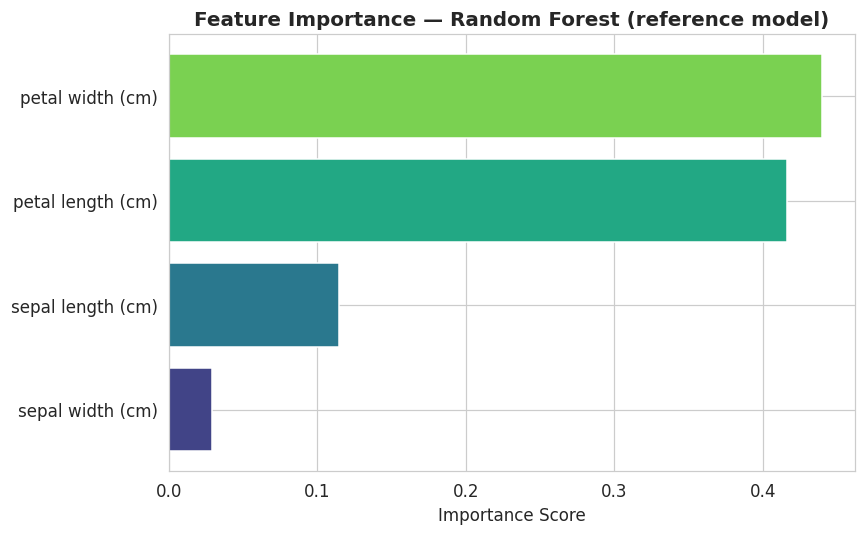

,Feature,Importance
3,petal width (cm),0.439768
2,petal length (cm),0.416405
0,sepal length (cm),0.114842
1,sepal width (cm),0.028985


In [23]:

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_source = BEST_MODEL_NAME
else:
    # Use Random Forest as an interpretability reference model
    rf_reference = trained_models["Random Forest"]
    importances = rf_reference.feature_importances_
    importance_source = "Random Forest (reference model)"

feat_imp_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color=sns.color_palette("viridis", len(feat_imp_df)))
plt.xlabel("Importance Score")
plt.title(f"Feature Importance — {importance_source}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

feat_imp_df.sort_values("Importance", ascending=False)
